Superstore Sales & Profitability Analysis

Objective:
Analyze sales, profitability, customer segments, products, regions, and discount patterns to identify business opportunities and profitability risks.

Tools: Python • NumPy • Pandas • Matplotlib • Seaborn

1. Which categories and sub-categories drive sales and profit?
2. Which products generate high sales but low/negative profit?
3. How does discounting affect profitability?
4. Which regions and customer segments perform best?
5. How does business performance change over time?
6. What actions could improve profitability?

In [1]:
import pandas as pd
import numpy as np

In [4]:
#Importing dataset
df=pd.read_csv('Sample - Superstore.csv',encoding='cp1252')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


2.Data Understanding
df.shape
df.info()
df.describe()
df.columns

The dataset contains transactional information covering orders, customers, products, geography, sales, quantity, discount and profit. The analysis focuses on identifying relationships between these variables and business performance.

In [8]:
#Overal info about dataframe structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [11]:
#Checking for null values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [12]:
df.shape

(9994, 21)

In [13]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [14]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

3. Data quality section
df.isnull().sum()
df.duplicated().sum()
df.dtypes

In [16]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [18]:
#Converting date field to date data type
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Profit_Margin"] = (
    df["Profit"] / df["Sales"]
) * 100
df["Order_Month"] = df["Order Date"].dt.month
df["Order_Year"] = df["Order Date"].dt.year

4.Jumping into analysis phase of project
   1. Overall business performance
       Total Sales
       Total Profit
       Total Quantity sold
       Average Order Value
       Number of orders
       Number of customers
       Overall profit margin

In [25]:
print("Overall business Performance")
print("-------------------------------------")
print("Total Sales:",df['Sales'].sum().round().astype(int))
print("Total Profit:",df['Profit'].sum().round().astype(int))
print("Total Quantity Sold:",df['Quantity'].sum().round().astype(int))
total_sales=df['Sales'].sum().round().astype(int)
Total_orders=df['Order ID'].count().astype(int)
print("Average Order Value:",(total_sales/Total_orders).round().astype(int))
print("Number of Orders:",Total_orders)
print("Number of customers:",df['Customer ID'].count().astype(int))
print("Overall Profit Margin:",df['Profit_Margin'].sum().astype(int))

Overall business Performance
-------------------------------------
Total Sales: 2297201
Total Profit: 286397
Total Quantity Sold: 37873
Average Order Value: 230
Number of Orders: 9994
Number of customers: 9994
Overall Profit Margin: 120241


2. Sales trend over time — VERY important

Analyze:

Sales by year
Sales by month
Profit by year
Profit by month
Quantity by month

Questions:

Are sales increasing?
Which month has the highest sales?
Which months have weak performance?
Is profit following the same trend as sales?

In [50]:
import matplotlib.pyplot as plt
month_order=['Jan','Feb','Mar','Apr','May','Jun',"Jul",'Aug','Sep','Oct','Nov','Dec']
df['Year'] = df['Order Date'].dt.year
df['Month_Num'] = df['Order Date'].dt.month
df['month']=pd.Categorical(df['Order Date'].dt.strftime('%b'),categories=month_order,ordered=True)


Year
2014    484247.0
2015    470533.0
2016    609206.0
2017    733215.0
Name: Sales, dtype: float64


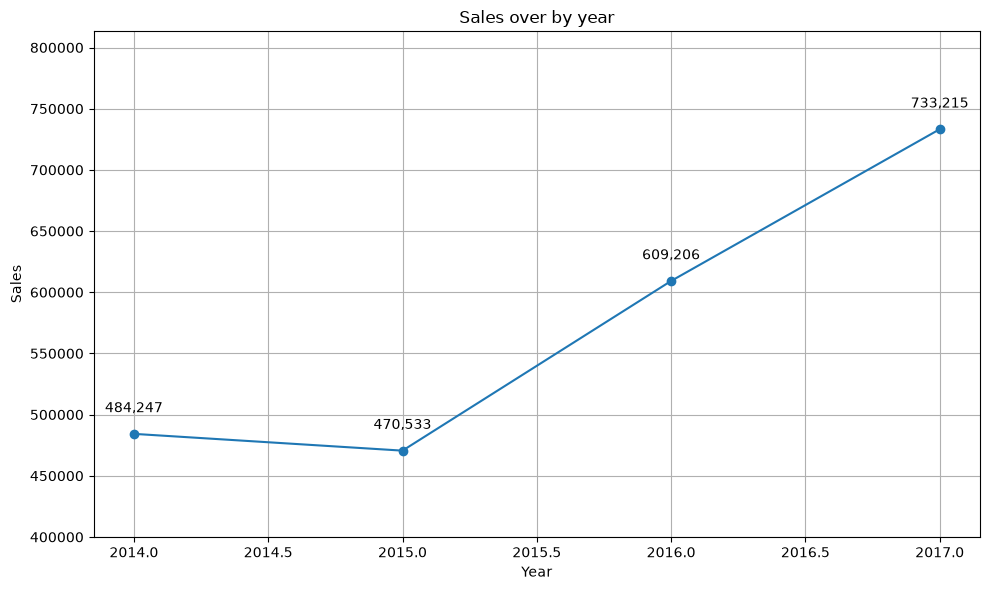

In [48]:
#Sales by year
sales_by_year=df.groupby('Year')['Sales'].sum().round()
ax=sales_by_year.plot(kind='line',title='Sales over by year',grid=True,figsize=(10,6),marker='o')
print(sales_by_year)
for x,y in sales_by_year.items():
    ax.text(
        x,
        y+15000,
        f'{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.ylim(400000,max(sales_by_year)+80000)
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

C:\Users\syeda\AppData\Local\Temp\ipykernel_1788\4108512587.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sale_month=df.groupby('month')['Sales'].sum().round()


month
Jan     94925.0
Feb     59751.0
Mar    205005.0
Apr    137762.0
May    155029.0
Jun    152719.0
Jul    147238.0
Aug    159044.0
Sep    307650.0
Oct    200323.0
Nov    352461.0
Dec    325294.0
Name: Sales, dtype: float64


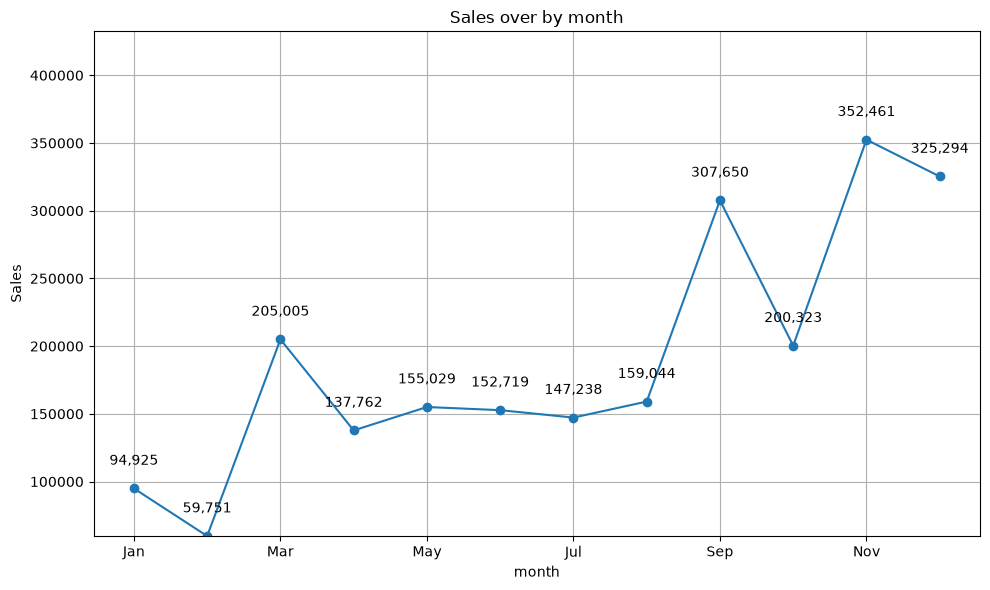

In [54]:
#Sales by month
sale_month=df.groupby('month')['Sales'].sum().round()
sale_month
pax=sale_month.plot(kind='line',title='Sales over by month',grid=True,figsize=(10,6),marker='o')
print(sale_month)
for x,(month,y) in enumerate(sale_month.items()):
    pax.text(
        x,
        y+15000,
        f'{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.ylim(min(sale_month),max(sale_month)+80000)
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

Year
2014    49544.0
2015    61619.0
2016    81795.0
2017    93439.0
Name: Profit, dtype: float64


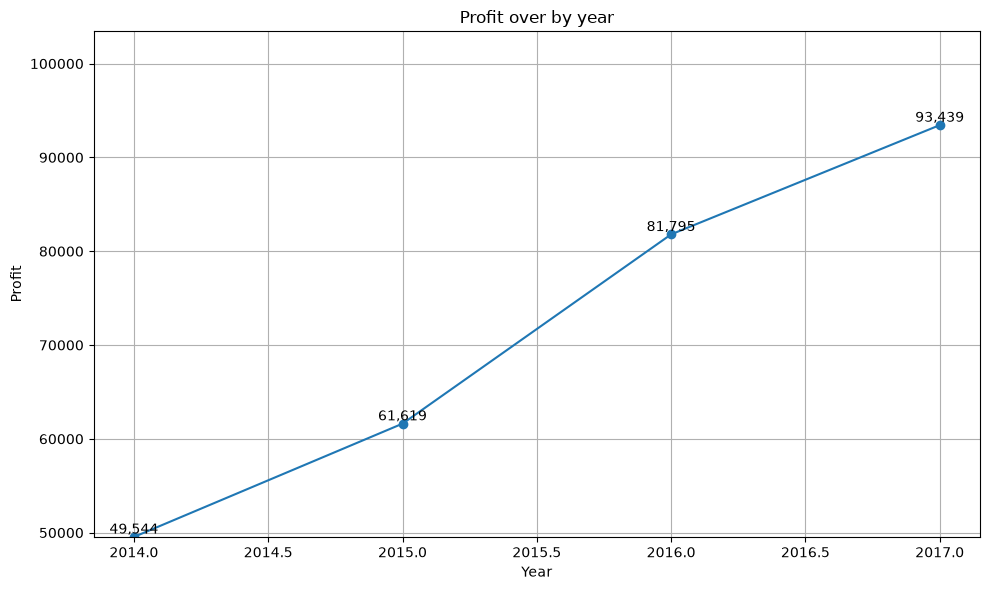

In [60]:
#Profit by year
profit_year=df.groupby('Year')['Profit'].sum().round()
profit_year
sax=profit_year.plot(kind='line',title='Profit over by year',grid=True,figsize=(10,6),marker='o')
print(profit_year)
for x,y in profit_year.items():
    sax.text(
        x,
        y,
        f'{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.ylim(min(profit_year),max(profit_year)+10000)
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

C:\Users\syeda\AppData\Local\Temp\ipykernel_1788\1401172787.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profit_month=df.groupby('month')['Profit'].sum().round()


month
Jan     9134.0
Feb    10295.0
Mar    28595.0
Apr    11587.0
May    22411.0
Jun    21286.0
Jul    13833.0
Aug    21777.0
Sep    36857.0
Oct    31784.0
Nov    35468.0
Dec    43369.0
Name: Profit, dtype: float64


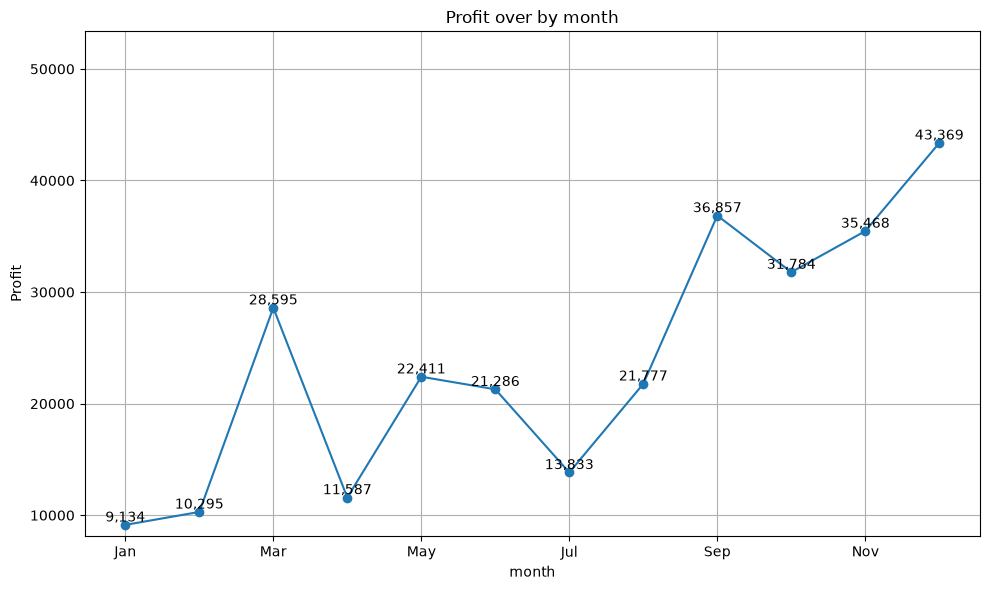

In [68]:
#Profit by month
profit_month=df.groupby('month')['Profit'].sum().round()
profit_month
tax=profit_month.plot(kind='line',title='Profit over by month',grid=True,figsize=(10,6),marker='o')
print(profit_month)
for x,(month,y) in enumerate(profit_month.items()):
    tax.text(
        x,
        y,
        f'{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.ylim(min(profit_month)-1000,max(profit_month)+10000)
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

C:\Users\syeda\AppData\Local\Temp\ipykernel_1788\2075430414.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  qty=df.groupby('month')['Quantity'].sum().round()


month
Jan    1475
Feb    1067
Mar    2564
Apr    2447
May    2791
Jun    2680
Jul    2705
Aug    2784
Sep    5062
Oct    3104
Nov    5775
Dec    5419
Name: Quantity, dtype: int64


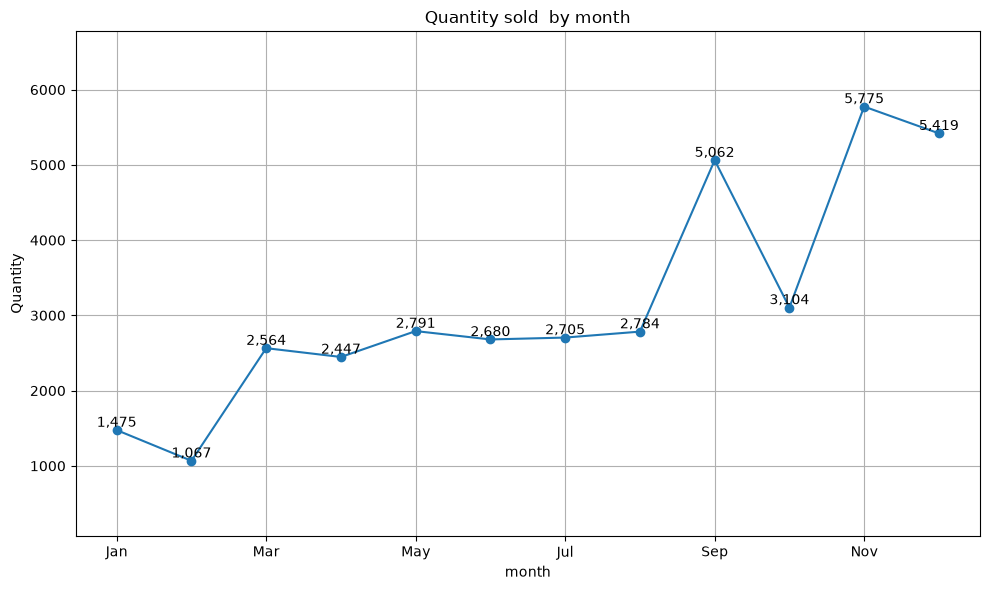

In [72]:
#Quantity by month
qty=df.groupby('month')['Quantity'].sum().round()
qty
ax=qty.plot(kind='line',title='Quantity sold  by month',grid=True,figsize=(10,6),marker='o')
print(qty)
for x,(month,y) in enumerate(qty.items()):
    ax.text(
        x,
        y,
        f'{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.ylim(min(qty)-1000,max(qty)+1000)
plt.ylabel('Quantity')
plt.tight_layout()
plt.show()


3. Category performance

Compare:

Furniture
Office Supplies
Technology

For each:

Sales
Profit
Quantity
Profit Margin

In [90]:
sal_cat=df.groupby('Category')['Sales'].sum().round()
print(sal_cat)
print("Highest sale category----->",sal_cat.idxmax())
print("-------------------------------------------")
pr_cat=df.groupby('Category')['Profit'].sum().round()
print(pr_cat)
print("Highest Profit Category---->",pr_cat.idxmax())
print("--------------------------------------------")
qt_cat=df.groupby('Category')['Quantity'].sum().round()
print(qt_cat)
print("Highest Quantity sold Category----->",qt_cat.idxmax())
print("------------------------------------------------")
cate_sum=df.groupby('Category')[['Sales','Profit']].sum().round()
cate_sum['Profit_margin_percent']=(cate_sum['Profit']/cate_sum['Sales'])*100
print("Profit_margin_category")
print((cate_sum))

Category
Furniture          742000.0
Office Supplies    719047.0
Technology         836154.0
Name: Sales, dtype: float64
Highest sale category-----> Technology
-------------------------------------------
Category
Furniture           18451.0
Office Supplies    122491.0
Technology         145455.0
Name: Profit, dtype: float64
Highest Profit Category----> Technology
--------------------------------------------
Category
Furniture           8028
Office Supplies    22906
Technology          6939
Name: Quantity, dtype: int64
Highest Quantity sold Category-----> Office Supplies
------------------------------------------------
Profit_margin_category
                    Sales    Profit  Profit_margin_percent
Category                                                  
Furniture        742000.0   18451.0               2.486658
Office Supplies  719047.0  122491.0              17.035187
Technology       836154.0  145455.0              17.395719
